/var/folders/h0/_4l965v12tg37k5f3s4xzyj40000gn/T/ipykernel_24462/4087549694.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range('2023-01-01', periods=time_steps, freq='H')


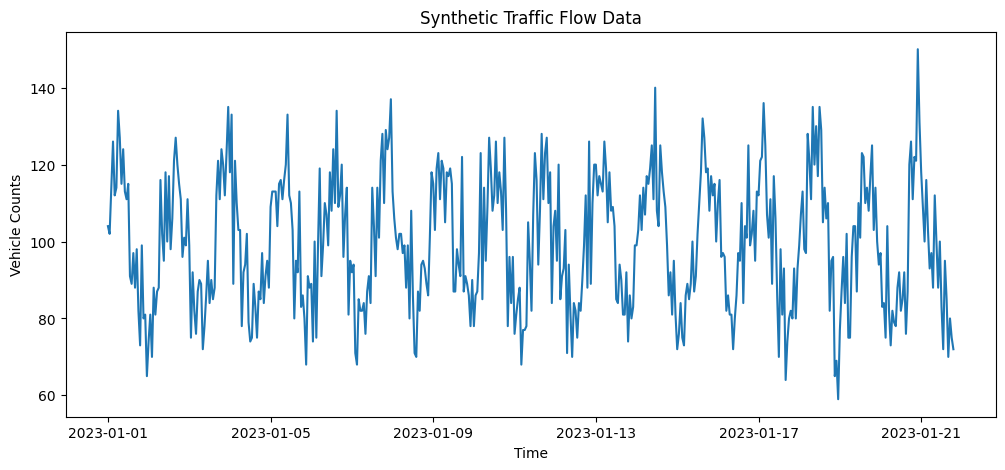

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
time_steps = 500
hours = pd.date_range('2023-01-01', periods=time_steps, freq='H')
vehicle_counts = np.abs(100 + 20 * np.sin(np.arange(time_steps) * 0.2) + np.random.normal(0, 10, time_steps)).astype(int)

traffic_data = pd.DataFrame({'timestamp': hours, 'vehicle_count': vehicle_counts})
traffic_data.to_csv('../data/processed/traffic_data.csv', index=False)

plt.figure(figsize=(12,5))
plt.plot(traffic_data.timestamp, traffic_data.vehicle_count)
plt.xlabel('Time')
plt.ylabel('Vehicle Counts')
plt.title('Synthetic Traffic Flow Data')
plt.show()


In [13]:
from sklearn.preprocessing import MinMaxScaler

# Load data
df = pd.read_csv('../data/processed/traffic_data.csv')
data = df['vehicle_count'].values.reshape(-1, 1)

# Scale data between 0 and 1
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X, y = create_sequences(data_scaled, seq_length)

# Train/Test split (80% train, 20% test)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)


ModuleNotFoundError: No module named 'sklearn'

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Model setup
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(seq_length, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Training
history = model.fit(X_train, y_train, epochs=30, batch_size=16, validation_data=(X_test, y_test))

# Plot training progress
plt.figure(figsize=(12,5))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.show()


/Users/khurshed/PycharmProjects/SmartTraffic/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


NameError: name 'seq_length' is not defined

In [ ]:
# Predict
y_pred_scaled = model.predict(X_test)

# Rescale back to original values
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test)

# Plot true vs predictions
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(y_true, label='True vehicle counts')
plt.plot(y_pred, label='Predicted vehicle counts')
plt.xlabel('Time step')
plt.ylabel('Vehicle Counts')
plt.legend()
plt.title('Traffic Flow Prediction (LSTM)')
plt.show()

